<a href="https://colab.research.google.com/github/yunayana/Sztuczna_Inteligencja_STAC_2026/blob/main/Lab5_LSTM_GRU_regresja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import bibliotek
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [ ]:
# Funkcje pomocnicze: wykres predykcji modelu, metryki oceny modelu RMSE i MAE)
# Jeśli RMSE jest dużo wyższe niż MAE, oznacza to, że model radzi sobie dobrze przez większość czasu,
# ale "wywala się" na kilku konkretnych dniach (np. przy nagłych krachach giełdowych).
def plot_predictions(test,predicted):
  plt.plot(test, color='red',label='Real IBM Stock Price')
  plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
  plt.title('IBM Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('IBM Stock Price')
  plt.legend()
  plt.show()
def return_rmse(test, predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("-" * 30)
  print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
  print("-" * 30)

def return_mae(test, predicted):
  mae = mean_absolute_error(test, predicted)
  mape = mean_absolute_percentage_error(test, predicted) * 100
  print("Średni błąd bezwzględny: {:.2f}.".format(mae))
  print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
  print("-" * 30)

In [ ]:
# Wczytanie danych
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [ ]:
# Ustawiamy zbiory trenujące i testowe oraz szukamy brakujących wartości
training_set = dataset[: '2016'].iloc[:,1:2].values
test_set = dataset[ '2017' : ].iloc[ :,1:2].values

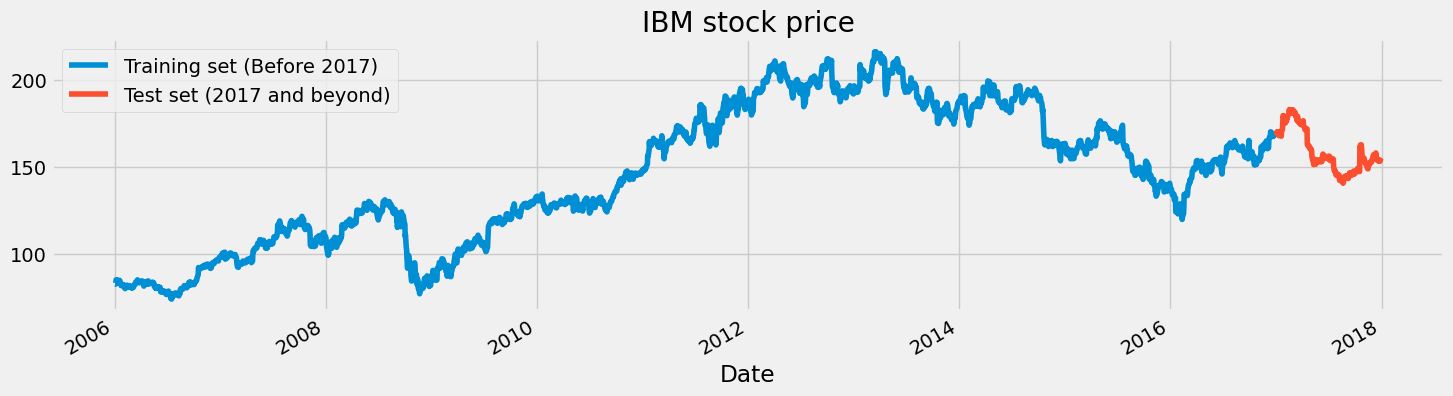

In [ ]:
# Wizualizacja danych
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017': ].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [ ]:
# Normalizacja danych trenujących
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
# Ponieważ komórki LSTM przechowują stan pamięci długotrwałej,
# tworzymy strukturę danych z 60 krokami czasowymi i 1 wyjściem
# Zatem dla każdego elementu zestawu treningowego mamy 60 poprzednich elementów zestawu treningowego.
x_train = []
y_train = []
for i in range(60,2769):
  x_train.append(training_set_scaled[i-60:i,0])
  y_train.append(training_set_scaled[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

In [ ]:
# Przekształcanie X_train w celu zapewnienia wydajnego modelowania
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

In [ ]:
from keras.losses import LogCosh

# Architektura LSTM, sieć regresyjna, predykująca
regressor = Sequential()
# Warstwa wejściowa
regressor.add(Input(shape=(x_train.shape[1],1)))
# Pierwsza warstwa LSTM
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
# Druga warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
# Trzecia warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
# Czwarta warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=100))
regressor.add(Dropout(0.2))
# Warstwa wyjściowa
regressor.add(Dense(units=1))

# Ustawaimy funkcję optymalizującą wagi (uczącą) i funkcję straty
regressor.compile(optimizer='adam',loss='mean_squared_error')

# Trenujemy sieć, ustawiamy ilość epok i ilość podawanych próbek ze zbioru trenującego
regressor.fit(x_train,y_train,epochs=50,batch_size=32)

# Wersja treningu z mechanizmem Early Stopping zapobiegającym przeuczeniu się sieci
# (zakomentować powyższe, odkomentować poniższe)
#early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
#regressor.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0210
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0038
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0028
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0028
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0027
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0023
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0021
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0019
Epoc

In [ ]:
# Teraz przygotujemy zestaw testowy w podobny sposób, jak zestaw treningowy.
# Poniższe czynności zostały wykonane tak,
# aby pierwsze 60 elementów zestawu testowego miało 60 poprzednich wartości
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017': ]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [ ]:
# Przygotowanie X_testu i predykcja cen akcji
x_test = []
for i in range(60,311):
  x_test.append(inputs[i-60:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test. shape[0],x_test. shape[1],1))
predicted_stock_price = regressor.predict(x_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


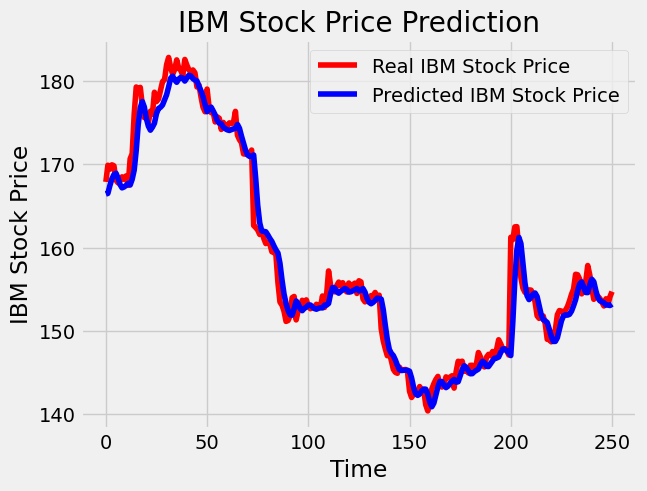

In [ ]:
# Wizualizacja wyników dla sieci LSTM
plot_predictions(test_set,predicted_stock_price)

In [ ]:
# Ocena modelu
return_rmse(test_set,predicted_stock_price)
return_mae(test_set,predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 2.09.
------------------------------
Średni błąd bezwzględny: 1.36.
Średni błąd bezwzględny procentowy: 0.85%
------------------------------


In [ ]:
# Architektura z bramką GRU
regressorGRU = Sequential()
# Warstwa wejściowa
regressorGRU.add(Input(shape=(x_train.shape[1], 1)))
# Pierwsza warstwa GRU z regularyzacją Dropout
regressorGRU.add (GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Druga warstwa GRU z regularyzacją Dropout
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Trzecia warstwa GRU z regularyzacją Dropout
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Czwarta warstwa GRU z regularyzacją Dropout
regressorGRU. add (GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Warstwa wyjściowa
regressorGRU. add(Dense(units=1))

# Ustawaimy funkcję optymalizującą wagi (uczącą) i funkcję straty
regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')

# Trenujemy sieć, ustawiamy ilość epok i ilość podawanych próbek ze zbioru trenującego
# wersja bez Early Stopping
#regressorGRU.fit(X_train,y_train,epochs=50,batch_size=32)

# Wersja treningu z mechanizmem Early Stopping zapobiegającym przeuczeniu się sieci
# (zakomentować powyższe, odkomentować poniższe)
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressorGRU. fit(x_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0154
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0084
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0070
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0055
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0060
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0047
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0043
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0042
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0040
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0036
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0037
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0032
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

In [ ]:
# Preparing X_test and predicting the prices
x_test = []
for i in range(60,311):
  x_test.append(inputs[i-60:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(x_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


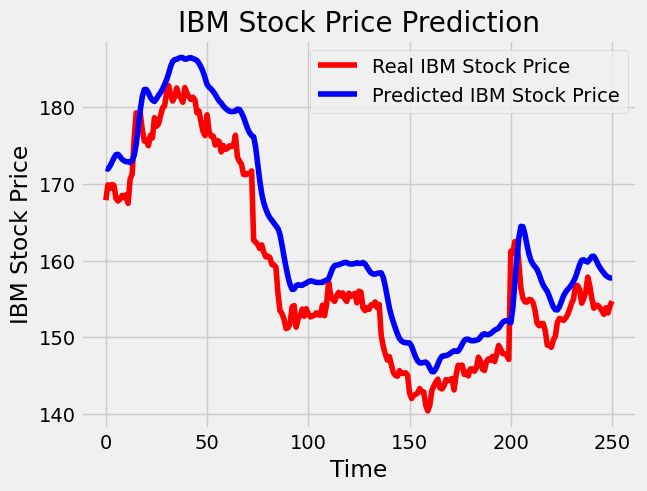

In [ ]:
# Wizualizacja wyników dla sieci GRU
plot_predictions(test_set, GRU_predicted_stock_price)

In [ ]:
# Ocena modelu
return_rmse(test_set,GRU_predicted_stock_price)
return_mae(test_set,GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 5.12.
------------------------------
Średni błąd bezwzględny: 4.75.
Średni błąd bezwzględny procentowy: 3.00%
------------------------------
